In [65]:
import pandas as pd 

df = pd.read_csv("Iris (1).csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [66]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [67]:
# Drop row has "'Iris-virginica'" in Species column
df = df[df["Species"] != "Iris-virginica"]
df["Species"].unique()


array(['Iris-setosa', 'Iris-versicolor'], dtype=object)

In [68]:

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
import numpy as np
# Chuyển đổi y thành 0 và 1
y = np.where(y == "Iris-setosa", 0, 1)

from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [69]:

from sklearn.preprocessing import StandardScaler
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


In [ ]:
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-10) + (1 - y_true) * np.log(1 - y_pred + 1e-10))

class LogisticRegression:
    def __init__(self, num_feature: int, num_row: int):
        self.num_feature = num_feature
        self.weights = np.random.randn(num_feature, 1)
        self.bias = np.random.randn(1, 1)
    
    def train(self, epochs: int, learning_rate: float, X_train, y_train, X_test, y_test):
        N = len(y_train)
        train_losses = []
        val_losses = []
        for epoch in range(epochs):
            output = X_train @ self.weights + self.bias # (N, 1)
            output = sigmoid(output) # (N, 1)
            # reshape output to vector
            output = output.reshape(-1) # (N,)
            train_cost = binary_cross_entropy(y_train, output) # (1,)
            train_losses.append(train_cost)
            
            error = output - y_train  # (N,)

            gradient_weights = (1 / N) * X_train.T @ error.reshape(-1, 1)
            gradient_bias = (1 / N) * np.sum(error)

            self.weights = self.weights - learning_rate * gradient_weights
            self.bias = self.bias - learning_rate * gradient_bias

            # validation
            output_test = X_test @ self.weights + self.bias
            output_test = sigmoid(output_test)
            val_cost = binary_cross_entropy(y_val, output_test.reshape(-1))
            val_losses.append(val_cost)
            
            output_test = output_test.reshape(-1)
            y_pred_test = np.where(output_test > 0.5, 1, 0)
            accuracy = np.mean(y_pred_test == y_test)
            
            if epoch % 10000 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Train Cost: {train_cost}, Val Accuracy: {accuracy}")
            
            # To do 
            # Implement early stopping
                
        return train_losses, val_losses
        
    def predict(self, X_test, threshold: float = 0.1):
        output = X_test @ self.weights + self.bias
        output = sigmoid(output) 
        y_pred = np.where(output > threshold, 1, 0)
        return y_pred
    
model = LogisticRegression(num_feature=X_train.shape[1], num_row=X_train.shape[0])
train_losses, val_losses = model.train(epochs=500000, learning_rate=0.002, y_train=y_train, X_train=X_train, X_test=X_val, y_test=y_val)

Epoch 1/500000, Train Cost: 2.178956011472632, Val Accuracy: 0.0625
Epoch 10001/500000, Train Cost: 0.019488022283520107, Val Accuracy: 1.0
Epoch 20001/500000, Train Cost: 0.009818314825988342, Val Accuracy: 1.0
Epoch 30001/500000, Train Cost: 0.006658972748430084, Val Accuracy: 1.0
Epoch 40001/500000, Train Cost: 0.005073457153639817, Val Accuracy: 1.0
Epoch 50001/500000, Train Cost: 0.004114381778901205, Val Accuracy: 1.0
Epoch 60001/500000, Train Cost: 0.003469265290404102, Val Accuracy: 1.0
Epoch 70001/500000, Train Cost: 0.003004428271741898, Val Accuracy: 1.0
Epoch 80001/500000, Train Cost: 0.002652916601434552, Val Accuracy: 1.0
Epoch 90001/500000, Train Cost: 0.002377410136524993, Val Accuracy: 1.0
Epoch 100001/500000, Train Cost: 0.0021554255309958253, Val Accuracy: 1.0
Epoch 110001/500000, Train Cost: 0.0019725920569915144, Val Accuracy: 1.0
Epoch 120001/500000, Train Cost: 0.0018192858374813966, Val Accuracy: 1.0
Epoch 130001/500000, Train Cost: 0.0016888140500285558, Val Ac

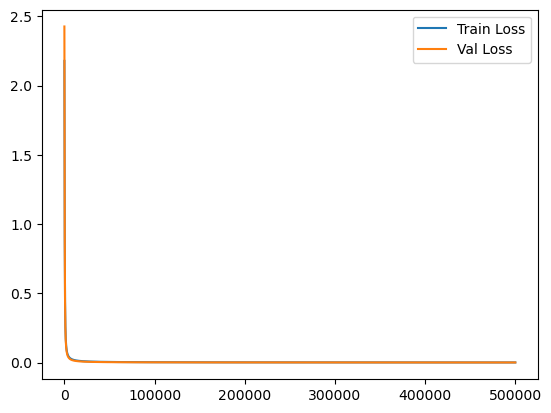

In [74]:
# draw train and val loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.show()

In [72]:
# Test model 
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, threshold=0.5)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

[[10  0]
 [ 0 10]]
